In [2]:
!pip uninstall matplotlib -y
!pip install matplotlib==3.7.1

Found existing installation: matplotlib 3.10.9
Uninstalling matplotlib-3.10.9:
  Successfully uninstalled matplotlib-3.10.9
Defaulting to user installation because normal site-packages is not writeable

  error: subprocess-exited-with-error
  
  exit code: 1
  
  [585 lines of output]
  C:\Users\dell i5 7th\AppData\Local\Temp\pip-build-env-bntx5gvy\overlay\Lib\site-packages\setuptools\dist.py:810: SetuptoolsDeprecationWarning: The namespace_packages parameter is deprecated.
  !!
  
          ********************************************************************************
          Please replace its usage with implicit namespaces (PEP 420).
  
          See https://setuptools.pypa.io/en/latest/references/keywords.html#keyword-namespace-packages for details.
          ********************************************************************************
  
  !!
    ep.load()(self, ep.name, value)
  toml section missing WindowsPath('pyproject.toml') does not contain any of the tool sections: ['setuptools_scm', 'vcs-versioning']
  C:\Users\dell i5 7th\AppData\Local\Temp\pip-build-env-bntx5gvy\overlay\Lib\site-packages\vcs_versioning\_backends\_git.py:474: UserWarning: git archive did not suppo


     ---------------------------------------- 0.0/38.0 MB ? eta -:--:--
     ---------------------------------------- 0.0/38.0 MB ? eta -:--:--
     ---------------------------------------- 0.0/38.0 MB ? eta -:--:--
     ---------------------------------------- 0.0/38.0 MB ? eta -:--:--
     ---------------------------------------- 0.3/38.0 MB ? eta -:--:--
     - -------------------------------------- 1.0/38.0 MB 4.5 MB/s eta 0:00:09
     - -------------------------------------- 1.0/38.0 MB 4.5 MB/s eta 0:00:09
     - -------------------------------------- 1.0/38.0 MB 4.5 MB/s eta 0:00:09
     - -------------------------------------- 1.3/38.0 MB 1.2 MB/s eta 0:00:32
     -- ------------------------------------- 2.1/38.0 MB 1.7 MB/s eta 0:00:22
     -- ------------------------------------- 2.1/38.0 MB 1.7 MB/s eta 0:00:22
     -- ------------------------------------- 2.1/38.0 MB 1.7 MB/s eta 0:00:22
     -- ------------------------------------- 2.4/38.0 MB 1.3 MB/s eta 0:00:28
     --

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import warnings
warnings.filterwarnings("ignore")
import yfinance as yf


ModuleNotFoundError: No module named 'matplotlib.backends.registry'

In [2]:
start = "2010-01-01"
end = "2025-12-31"

In [4]:
data = yf.download("AAPL",start,end)

[*********************100%***********************]  1 of 1 completed


In [5]:
data = data.reset_index()

In [6]:
data = data.drop(columns = ["Date"],axis=1)

In [7]:
data.head()

Price,Close,High,Low,Open,Volume
Ticker,AAPL,AAPL,AAPL,AAPL,AAPL
0,6.412384,6.427065,6.363544,6.395005,493729600
1,6.423468,6.459723,6.389610,6.430060,601904800
2,6.321295,6.448937,6.314703,6.423469,552160000
3,6.309609,6.352157,6.263766,6.344666,477131200
4,6.351557,6.352157,6.264066,6.301219,447610800


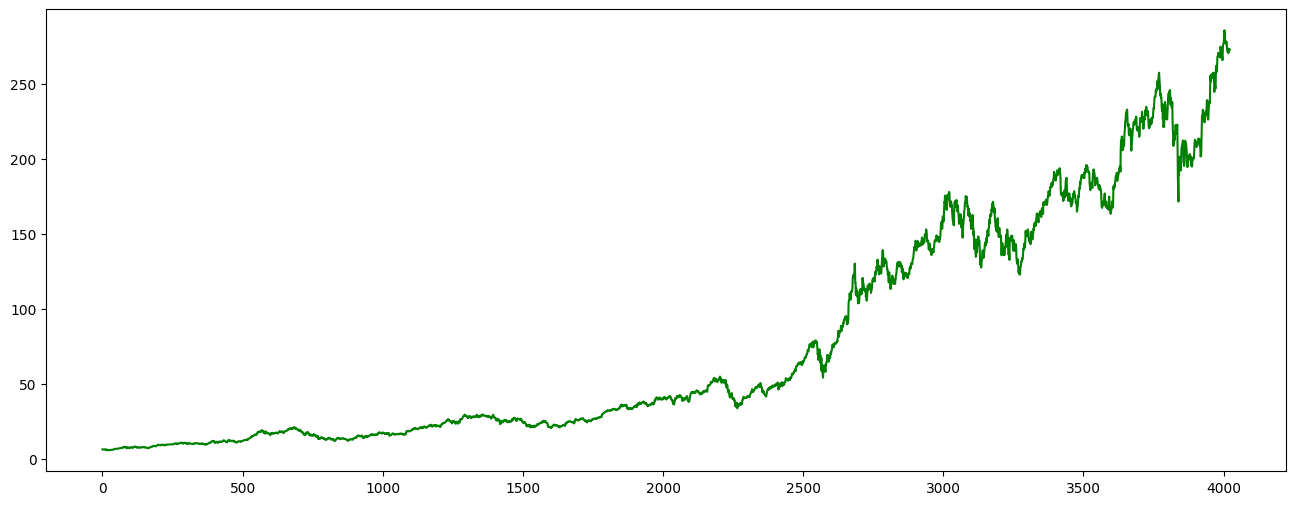

In [8]:
plt.figure(figsize=(16,6))
plt.plot(data.Close,'g')
plt.show()

In [9]:
MA100 = data.Close.rolling(100).mean()
MA200 = data.Close.rolling(200).mean()

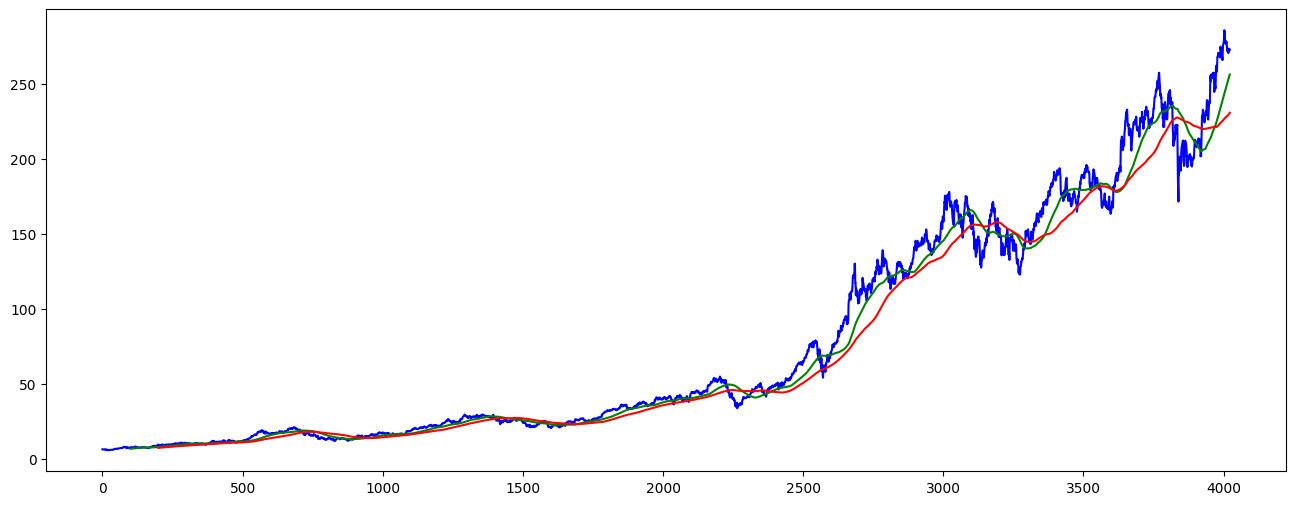

In [10]:
plt.figure(figsize=(16,6))
plt.plot(data.Close,'b')
plt.plot(MA100,'g')
plt.plot(MA200,'r')
plt.show()

In [11]:
from sklearn.preprocessing import MinMaxScaler

In [12]:
data_training = pd.DataFrame(data["Close"][0:int(len(data)*0.70)])
data_testing = pd.DataFrame(data["Close"][int(len(data)*0.70):int(len(data))])

print(data_training)
print(data_testing)

Ticker        AAPL
0         6.412384
1         6.423468
2         6.321295
3         6.309609
4         6.351557
...            ...
2811    118.262520
2812    113.334137
2813    117.941124
2814    116.859978
2815    118.788490

[2816 rows x 1 columns]
Ticker        AAPL
2816    117.882675
2817    120.765701
2818    122.304626
2819    121.515686
2820    117.395691
...            ...
4018    272.105377
4019    273.554016
4020    273.144409
4021    273.504089
4022    272.824707

[1207 rows x 1 columns]


In [13]:
scaler = MinMaxScaler(feature_range=(-1,1))
data_training_scaled = scaler.fit_transform(data_training)
data_testing_scaled = scaler.fit_transform(data_testing)

In [14]:
print(data_training_scaled.shape)
print(data_testing_scaled.shape)

(2816, 1)
(1207, 1)


In [15]:
print(data_training_scaled)
print(data_testing_scaled)

[[-0.99014066]
 [-0.98997457]
 [-0.99150554]
 ...
 [ 0.68101786]
 [ 0.66481785]
 [ 0.69371488]]
[[-0.98698568]
 [-0.95289534]
 [-0.93469833]
 ...
 [ 0.84890605]
 [ 0.85315909]
 [ 0.84512574]]


In [16]:
X_train = []
y_train = []

for i in range(100,data_training_scaled.shape[0]):
    X_train.append(data_training_scaled[i-100:i])
    y_train.append(data_training_scaled[i,0])

# now lets convert this into a numpy array
X_train,y_train = np.array(X_train),np.array(y_train)
print(X_train)
print("************")
print(y_train)

[[[-0.99014066]
  [-0.98997457]
  [-0.99150554]
  ...
  [-0.97543698]
  [-0.97612841]
  [-0.97662667]]

 [[-0.98997457]
  [-0.99150554]
  [-0.99168064]
  ...
  [-0.97612841]
  [-0.97662667]
  [-0.97247831]]

 [[-0.99150554]
  [-0.99168064]
  [-0.99105209]
  ...
  [-0.97662667]
  [-0.97247831]
  [-0.97089332]]

 ...

 [[ 0.6754873 ]
  [ 0.67679649]
  [ 0.66981373]
  ...
  [ 0.66700707]
  [ 0.68583369]
  [ 0.61198627]]

 [[ 0.67679649]
  [ 0.66981373]
  [ 0.64522814]
  ...
  [ 0.68583369]
  [ 0.61198627]
  [ 0.68101786]]

 [[ 0.66981373]
  [ 0.64522814]
  [ 0.60100347]
  ...
  [ 0.61198627]
  [ 0.68101786]
  [ 0.66481785]]]
************
[-0.97247831 -0.97089332 -0.96911994 ...  0.68101786  0.66481785
  0.69371488]


In [17]:
X_train.shape

(2716, 100, 1)

In [18]:
import tensorflow
from tensorflow import keras
from tensorflow.keras import Sequential
from tensorflow.keras.layers import Dense,Dropout,LSTM
from tensorflow.keras.callbacks import EarlyStopping

In [ ]:
model = Sequential()
model.add(LSTM(units=50 , activation='tanh' , return_sequences=True,input_shape = (X_train.shape[1],1)))
model.add(Dropout(0.2))

model.add(LSTM(units=60,activation = "tanh", return_sequences=True))
model.add(Dropout(0.2))

model.add(LSTM(units=60,activation='tanh'))
model.add(Dropout(0.2))
model.add(Dropout(0.2))

model.add(Dense(1))

In [ ]:
model.summary()

In [ ]:
early_stop = EarlyStopping(
    monitor = 'val_loss',
    patience = 10,
    restore_best_weights =True
)
model.compile(optimizer='adam',loss='mean_squared_error',metrics=['mae','mse'])
history = model.fit(X_train,y_train,epochs =13,validation_split = 0.2,callbacks=[early_stop])

In [ ]:
plt.plot(history.history['loss'], label='train')
plt.plot(history.history['val_loss'], label='val_loss')
plt.plot(history.history['mae'], label='mae')
plt.plot(history.history['val_mae'], label='val_mae')
plt.legend()

In [ ]:
model.save("keras_modell.h5")

In [ ]:
data_testing.head()

In [ ]:
past100Days = data_training.tail(100)
past100Days

In [ ]:
final_data = pd.concat([past100Days,data_testing],ignore_index=True)
final_data

In [ ]:
input_data = scaler.transform(final_data)
input_data

In [ ]:
input_data.shape

In [ ]:
X_test = []
y_test = []

for i in range(150,input_data.shape[0]):
    X_test.append(input_data[i-150:i])
    y_test.append(input_data[i,0])

X_test,y_test = np.array(X_test),np.array(y_test)
print(X_test.shape)
print(y_test.shape)

In [ ]:
y_predicted = model.predict(X_test)

In [ ]:
y_predicted.shape

In [ ]:
y_test

In [ ]:
y_predicted

In [ ]:
y_predicted = scaler.inverse_transform(y_predicted.reshape(-1,1))
y_test = scaler.inverse_transform(y_test.reshape(-1,1))

In [ ]:
plt.figure(figsize=(15,6))
plt.plot(y_test,'g',label="Original Price")
plt.plot(y_predicted,'r',label="Predicted Price")
plt.xlabel("Time")
plt.ylabel("Price")
plt.legend("")
plt.title("The Diffrence between Orig VS Pred Prices")
plt.show()

In [ ]:
print(tensorflow.__version__)


In [ ]:
import joblib
joblib.dump(scaler, 'scaler.pkl')

**NOW LETS MAKE MODEL FOR OPENING PRICE**

In [32]:
data = yf.download("AAPL",start,end)

[*********************100%***********************]  1 of 1 completed


In [33]:
data.reset_index()

Price,Date,Close,High,Low,Open,Volume
Ticker,,AAPL,AAPL,AAPL,AAPL,AAPL
0,2010-01-04,6.412384,6.427065,6.363544,6.395005,493729600
1,2010-01-05,6.423468,6.459723,6.389610,6.430060,601904800
2,2010-01-06,6.321295,6.448937,6.314703,6.423469,552160000
3,2010-01-07,6.309609,6.352157,6.263766,6.344666,477131200
4,2010-01-08,6.351557,6.352157,6.264066,6.301219,447610800
...,...,...,...,...,...,...
4018,2025-12-23,272.105377,272.245261,269.308007,270.586809,29642000
4019,2025-12-24,273.554016,275.172497,271.945536,272.085389,17910600
4020,2025-12-26,273.144409,275.112569,272.604905,273.903708,21521800


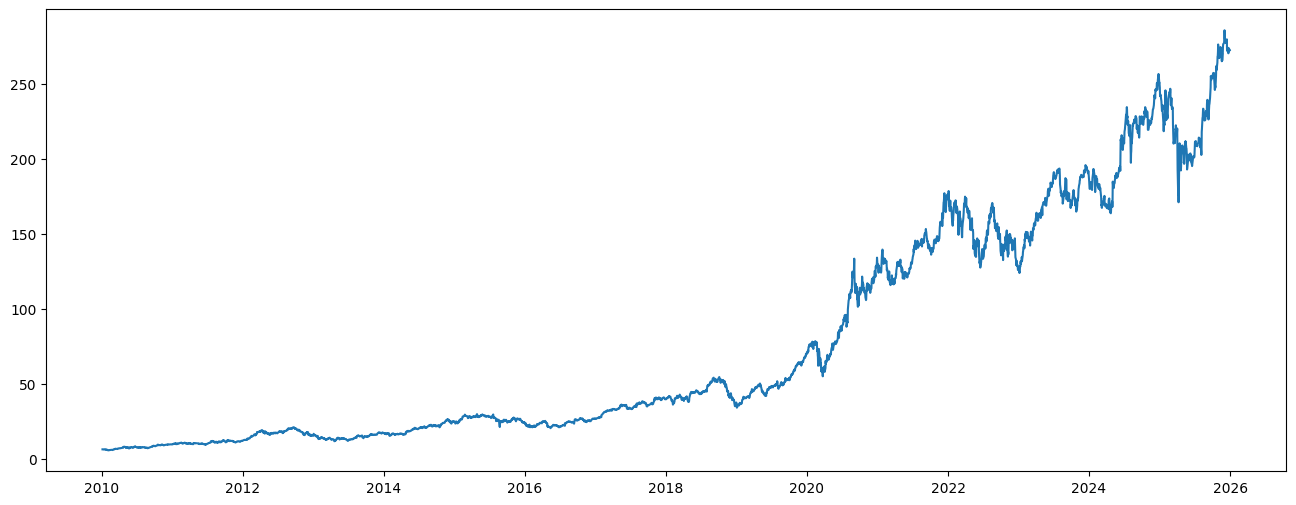

In [36]:
plt.figure(figsize=(16,6))
plt.plot(data.Open)
plt.show()

In [37]:
MA100 = data.Open.rolling(100).mean()
MA200 = data.Open.rolling(200).mean()

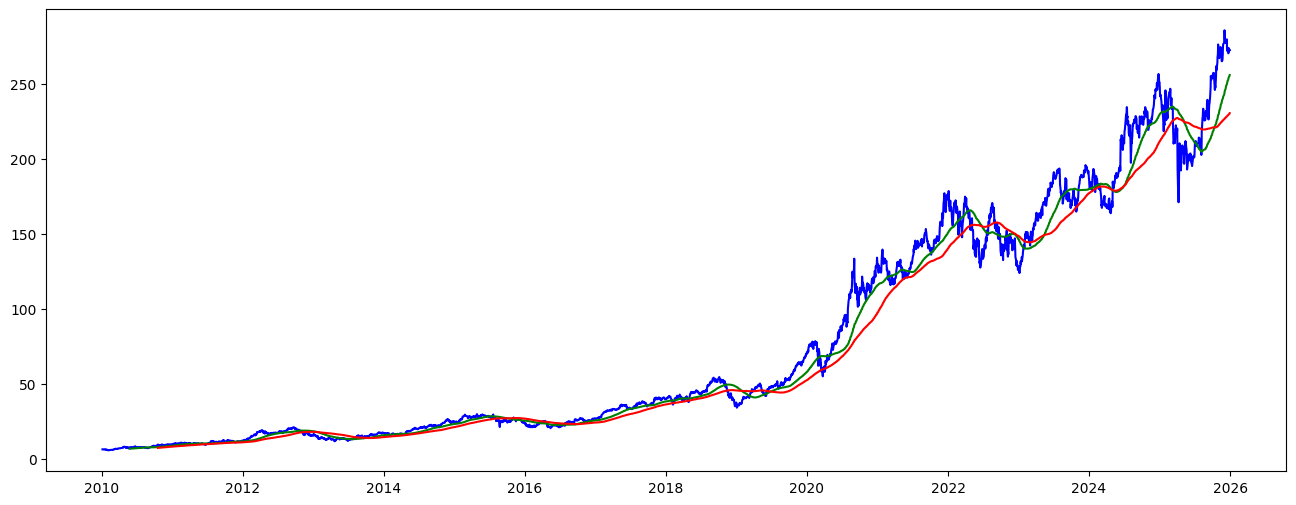

In [38]:
plt.figure(figsize=(16,6))
plt.plot(data.Open,'b')
plt.plot(MA100,'g')
plt.plot(MA200,'r')
plt.show()


In [39]:
Odata_trainig = pd.DataFrame(data["Open"][0:int(len(data)*0.70)])
Odata_testing = pd.DataFrame(data["Open"][int(len(data)*0.70):int(len(data))])

print(f"Shape of Training is : {Odata_trainig.shape}")
print(f"Shape of Testing is : {Odata_testing.shape}")

Shape of Training is : (2816, 1)
Shape of Testing is : (1207, 1)


In [40]:
scaler = MinMaxScaler(feature_range=(-1,1))
Odata_training_scl = scaler.fit_transform(Odata_trainig)
Odata_testing_scl = scaler.fit_transform(Odata_testing)

In [41]:
X_train = [] 
y_train = [] 

for i in range(100,Odata_training_scl.shape[0]):
    X_train.append(Odata_training_scl[i-100:i])
    y_train.append(Odata_training_scl[i,0])

X_train,y_train = np.array(X_train) , np.array(y_train)

In [42]:
model2 = Sequential()
model2.add(LSTM(units=50,activation='tanh',return_sequences=True,input_shape=(X_train.shape[1],1)))
# model.add(LSTM(units=50 , activation='tanh' , return_sequences=True,input_shape = (X_train.shape[1],1)))
model2.add(Dropout(0.2))

model2.add(LSTM(units = 55 ,activation='tanh',return_sequences=True))
model2.add(Dropout(0.2))

model2.add(LSTM(units=60 ,activation='tanh'))
model2.add(Dropout(0.2))
model2.add(Dropout(0.2))

model2.add(Dense(1))

In [43]:
model2.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━┓
┃ Layer (type)                         ┃ Output Shape                ┃         Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━┩
│ lstm (LSTM)                          │ (None, 100, 50)             │          10,400 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dropout (Dropout)                    │ (None, 100, 50)             │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ lstm_1 (LSTM)                        │ (None, 100, 55)             │          23,320 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dropout_1 (Dropout)                  │ (None, 100, 55)             │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ lstm_2 (LSTM)                        │ (None, 60)                  │          27,840 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dropout_2 (Dropout)                  │ (None, 60)                  │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dropout_3 (Dropout)                  │ (None, 60)                  │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense (Dense)                        │ (None, 1)                   │              61 │
└──────────────────────────────────────┴─────────────────────────────┴─────────────────┘

 Total params: 61,621 (240.71 KB)

 Trainable params: 61,621 (240.71 KB)

 Non-trainable params: 0 (0.00 B)

In [44]:
early_stop = EarlyStopping(
    monitor = 'val_loss',
    patience = 10,
    restore_best_weights =True
)
model2.compile(optimizer='adam',loss='mean_squared_error',metrics=['mae','mse'])
history = model2.fit(X_train,y_train,epochs =50,validation_split = 0.2,callbacks=[early_stop])

Epoch 1/50
68/68 ━━━━━━━━━━━━━━━━━━━━ 24s 193ms/step - loss: 0.0440 - mae: 0.1399 - mse: 0.0440 - val_loss: 0.0421 - val_mae: 0.1658 - val_mse: 0.0421
Epoch 2/50
68/68 ━━━━━━━━━━━━━━━━━━━━ 12s 179ms/step - loss: 0.0092 - mae: 0.0748 - mse: 0.0092 - val_loss: 0.0240 - val_mae: 0.1119 - val_mse: 0.0240
Epoch 3/50
68/68 ━━━━━━━━━━━━━━━━━━━━ 12s 179ms/step - loss: 0.0088 - mae: 0.0731 - mse: 0.0088 - val_loss: 0.0180 - val_mae: 0.1030 - val_mse: 0.0180
Epoch 4/50
68/68 ━━━━━━━━━━━━━━━━━━━━ 12s 182ms/step - loss: 0.0078 - mae: 0.0689 - mse: 0.0078 - val_loss: 0.0163 - val_mae: 0.0894 - val_mse: 0.0163
Epoch 5/50
68/68 ━━━━━━━━━━━━━━━━━━━━ 12s 177ms/step - loss: 0.0065 - mae: 0.0636 - mse: 0.0065 - val_loss: 0.0134 - val_mae: 0.0855 - val_mse: 0.0134
Epoch 6/50
68/68 ━━━━━━━━━━━━━━━━━━━━ 12s 177ms/step - loss: 0.0070 - mae: 0.0661 - mse: 0.0070 - val_loss: 0.0121 - val_mae: 0.0752 - val_mse: 0.0121
Epoch 7/50
68/68 ━━━━━━━━━━━━━━━━━━━━ 21s 176ms/step - loss: 0.0070 - mae: 0.0654 - mse: 0.007

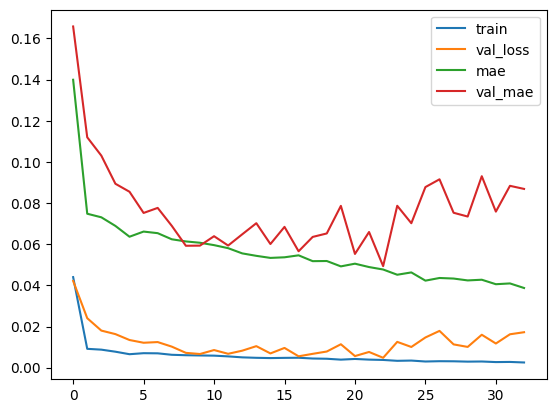

In [45]:
plt.plot(history.history['loss'], label='train')
plt.plot(history.history['val_loss'], label='val_loss')
plt.plot(history.history['mae'], label='mae')
plt.plot(history.history['val_mae'], label='val_mae')
plt.legend()

In [46]:
model2.save("Opnkeras_model.h5")

In [47]:
Odata_testing.head()

Ticker,AAPL
Date,
2021-03-12,117.269061
2021-03-15,118.252799
2021-03-16,122.431243
2021-03-17,120.824150
2021-03-18,119.684579


In [52]:
Odata_testing.reset_index()

Ticker,Date,AAPL
0,2021-03-12,117.269061
1,2021-03-15,118.252799
2,2021-03-16,122.431243
3,2021-03-17,120.824150
4,2021-03-18,119.684579
...,...,...
1202,2025-12-23,270.586809
1203,2025-12-24,272.085389
1204,2025-12-26,273.903708
1205,2025-12-29,272.435082


In [53]:
Odata_testing

Ticker,AAPL
Date,
2021-03-12,117.269061
2021-03-15,118.252799
2021-03-16,122.431243
2021-03-17,120.824150
2021-03-18,119.684579
...,...
2025-12-23,270.586809
2025-12-24,272.085389
2025-12-26,273.903708


In [54]:
past100Days = Odata_trainig.tail(100)
past100Days

Ticker,AAPL
Date,
2020-10-16,117.746774
2020-10-19,116.465220
2020-10-20,112.814768
2020-10-21,113.271093
2020-10-22,114.028371
...,...
2021-03-05,117.833967
2021-03-08,117.785297
2021-03-09,115.934695


In [56]:
final_data =pd.concat([past100Days,Odata_testing],ignore_index=True)
final_data

Ticker,AAPL
0,117.746774
1,116.465220
2,112.814768
3,113.271093
4,114.028371
...,...
1302,270.586809
1303,272.085389
1304,273.903708
1305,272.435082


In [57]:
input_data = scaler.transform(final_data)
input_data.shape

(1307, 1)

In [59]:
X_test = []
y_test = []

for i in range(100,input_data.shape[0]):
    X_test.append(input_data[i-100:i])
    y_test.append(input_data[i,0])

X_test,y_test = np.array(X_test) , np.array(y_test)

print(f"The Shape Of X_test Is  : {X_test.shape[0]}")
print(f"The Shape Of y_test Is  : {y_test.shape[0]}")

The Shape Of X_test Is  : 1207
The Shape Of y_test Is  : 1207


In [60]:
y_predicted = model2.predict(X_test)

38/38 ━━━━━━━━━━━━━━━━━━━━ 5s 94ms/step


In [61]:
y_predicted = scaler.inverse_transform(y_predicted.reshape(-1,1))
y_test = scaler.inverse_transform(y_test.reshape(-1,1))

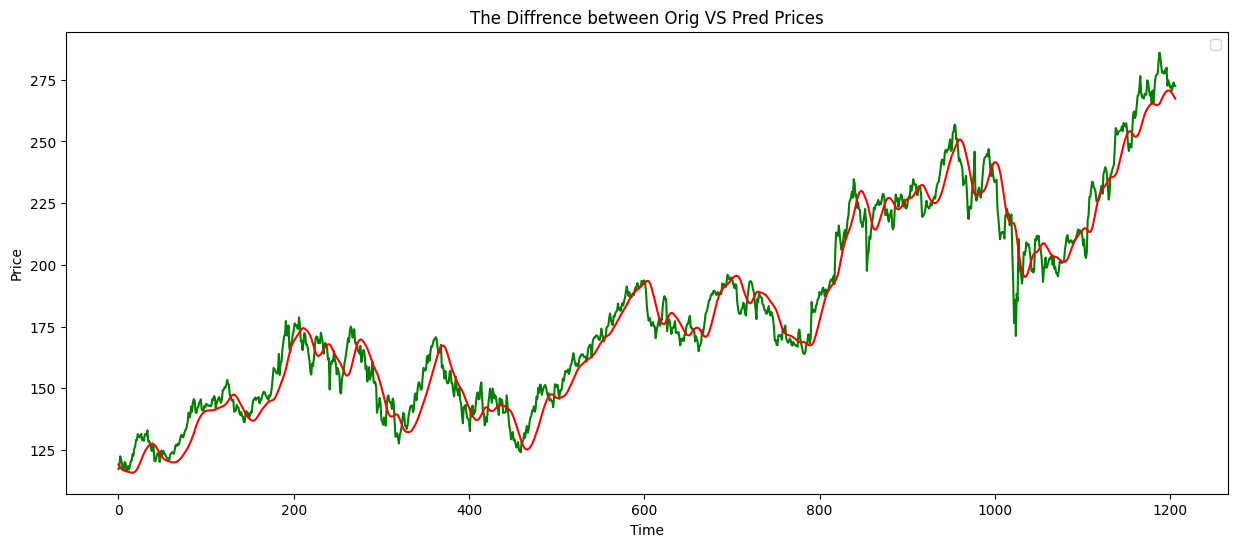

In [62]:
plt.figure(figsize=(15,6))
plt.plot(y_test,'g',label="Original Price")
plt.plot(y_predicted,'r',label="Predicted Price")
plt.xlabel("Time")
plt.ylabel("Price")
plt.legend("")
plt.title("The Diffrence between Orig VS Pred Prices")
plt.show()

NOW LETS MAKE MODEL FOR THE HIGH:

: 